# Word-KD + Attention Transfer (BLIP-large -> BLIP-base pruned decoder) — 12 -> 4 layers


In [1]:
# Kaggle thuong co san torch; bo sung thu vien danh gia/tai du lieu + optuna.
!pip install -q -U "transformers>=4.41" accelerate huggingface_hub
!pip install -q pycocoevalcap rouge_score evaluate nltk optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 52.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 66.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 36.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 16.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


In [2]:
import gc
import json
import logging
import os
import random
import time
from dataclasses import dataclass, field, replace
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from PIL import Image
from torch.optim import AdamW
from transformers import (
    BlipForConditionalGeneration,
    BlipProcessor,
    LogitsProcessor,
    LogitsProcessorList,
    get_linear_schedule_with_warmup,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("word_at_kd")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS = torch.cuda.device_count()
logger.info(f"CUDA available: {torch.cuda.is_available()} | So GPU: {N_GPUS}")


17:58:37 | INFO    | CUDA available: True | So GPU: 2


## 1. Cấu hình (dataclass — không hardcode tham số trong logic phía dưới)

In [3]:
@dataclass
class DataConfig:
    hf_repo_id: str = "qa994/fashion200k_10k"
    train_zip: str = "fashion200k_train.zip"
    val_zip: str = "fashion200k_val.zip"
    test_zip: str = "fashion200k_test.zip"
    cache_dir: str = "/kaggle/working/hf_cache"


@dataclass
class ArchConfig:
    teacher_name: str = "Salesforce/blip-image-captioning-large"
    student_name: str = "Salesforce/blip-image-captioning-base"
    # Giu prune 12->4 tang decoder (giu loi ich nen kich thuoc da dat duoc o pp1_2).
    keep_decoder_layers: Tuple[int, ...] = (0, 3, 6, 9)
    hint_fractions: Tuple[float, ...] = (0.25, 0.5, 0.75, 1.0)


@dataclass
class GenConfig:
    """Cau hinh sinh caption — uu tien tranh caption cut / lap tu / vo nghia.

    So voi pp1_2: tang max_new_tokens (32 -> 64) vi 32 token thuong khong du cho 2 cau hoan
    chinh trong domain thoi trang (caption tieng Anh trung binh 15-25 token/cau). min_sentences
    duoc ep bang LogitsProcessor rieng (xem MinSentenceLogitsProcessor ben duoi), KHONG chi dua
    vao min_new_tokens (min_new_tokens chi ep DO DAI, khong ep CAU TRUC cau).
    """
    num_beams: int = 1
    max_new_tokens: int = 64
    min_new_tokens: int = 12
    no_repeat_ngram_size: int = 3
    repetition_penalty: float = 1.3
    use_cache: bool = True
    min_sentences: int = 2  # yeu cau moi: caption phai co >= 2 cau hoan chinh

    def as_kwargs(self) -> dict:
        return {
            "num_beams": self.num_beams,
            "max_new_tokens": self.max_new_tokens,
            "min_new_tokens": self.min_new_tokens,
            "no_repeat_ngram_size": self.no_repeat_ngram_size,
            "repetition_penalty": self.repetition_penalty,
            "use_cache": self.use_cache,
        }


@dataclass
class TrainConfig:
    # Tang so epoch so voi pp1_2 (6 -> 12) nhung dua vao early stopping de khong lang phi neu
    # hoi tu som; v4_fixed dung 10 epoch va cho chat luong tot hon nhieu, 12 + early-stop la
    # muc an toan hop ly trong quy Kaggle T4.
    num_epochs: int = 12
    batch_size: int = 4
    grad_accum_steps: int = 1
    lr: float = 1e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm: float = 1.0
    temperature: float = 4.0
    lambda_response: float = 1.0
    lambda_feature: float = 1.0
    use_amp: bool = True

    # Teacher fine-tune: tang tro lai 10 epoch (giong v4_fixed) vi Teacher yeu -> tin hieu KD yeu.
    teacher_ft_epochs: int = 10
    teacher_ft_lr: float = 5e-6
    teacher_ft_batch_size: int = 2

    max_len: int = 64  # dong bo voi v4_fixed (48 -> 64), tranh cat cut caption dai luc train

    # Early stopping that (pp1_2 chi luu best checkpoint nhung van chay het so epoch).
    early_stop_patience: int = 3
    early_stop_min_delta: float = 1e-4


@dataclass
class RunConfig:
    output_root: str = "/kaggle/working/word_at_kd_outputs"
    teacher_checkpoint_uri: Optional[str] = None
    method_name: str = "at"  # Word-KD (response, luon bat) + Attention Transfer (feature)
    debug_mode: bool = False  # Cell DEBUG doc bien nay; dat False truoc khi chay FULL


data_cfg = DataConfig()
arch_cfg = ArchConfig()
gen_cfg = GenConfig()
train_cfg = TrainConfig()
run_cfg = RunConfig()

os.makedirs(run_cfg.output_root, exist_ok=True)
logger.info(f"method_name = {run_cfg.method_name}")


17:58:37 | INFO    | method_name = at


## 2. Tải dữ liệu (train/val/test cố định 7/1/2) từ HuggingFace Hub

In [4]:
def load_split_from_hf(repo_id: str, filename: str, split_name: str, cache_dir: str) -> List[dict]:
    """Tai 1 file zip split tu HF Hub, giai nen, doc metadata.json.

    Args:
        repo_id: ten dataset repo tren HF Hub.
        filename: ten file zip trong repo.
        split_name: 'train' | 'val' | 'test'.
        cache_dir: thu muc luu cache/giai nen.

    Returns:
        Danh sach dict, moi dict co them khoa 'image_path'.

    Raises:
        RuntimeError: neu tai hoac giai nen that bai.
    """
    try:
        zip_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset", cache_dir=cache_dir)
    except (OSError, ValueError) as e:
        raise RuntimeError(f"Khong tai duoc {filename} tu {repo_id}: {e}") from e

    target_dir = os.path.join(cache_dir, f"extracted_{split_name}")
    if not os.path.exists(target_dir):
        import zipfile
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(target_dir)
        except zipfile.BadZipFile as e:
            raise RuntimeError(f"File zip loi: {filename}: {e}") from e

    meta_path = os.path.join(target_dir, "metadata.json")
    with open(meta_path, encoding="utf-8") as f:
        metadata = json.load(f)
    for item in metadata:
        item["image_path"] = os.path.join(target_dir, item["image_file"])
    logger.info(f"[{split_name}] Da tai {len(metadata)} mau tu {filename}")
    return metadata


SHARED_PROCESSOR = BlipProcessor.from_pretrained(arch_cfg.student_name)
PAD_ID = SHARED_PROCESSOR.tokenizer.pad_token_id

fashion_train = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.train_zip, "train", data_cfg.cache_dir)
fashion_val = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.val_zip, "val", data_cfg.cache_dir)
fashion_test = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.test_zip, "test", data_cfg.cache_dir)
logger.info(f"Train: {len(fashion_train)} | Val: {len(fashion_val)} | Test: {len(fashion_test)}")


17:58:37 | INFO    | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
17:58:37 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
17:58:38 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
17:58:38 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
17:58:38 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
17:58:38 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
17:58:38 | INFO    | HTTP Request: HEAD https://huggingface.co

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

17:58:39 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
17:58:39 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
17:58:39 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/preprocessor_config.json "HTTP/1.1 200 OK"
17:58:39 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
17:58:39 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
17:58:39 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Salesforce/b

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

17:58:40 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
17:58:40 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/tokenizer_config.json "HTTP/1.1 200 OK"
17:58:40 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/tokenizer_config.json "HTTP/1.1 200 OK"


...

fashion200k_val.zip: downloading bytes:           |  0.00B            

17:58:59 | INFO    | [val] Da tai 1001 mau tu fashion200k_val.zip
17:58:59 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_test.zip "HTTP/1.1 302 Found"


fashion200k_test.zip: reconstructing file:   0%|          |  0.00B / 59.7MB            

fashion200k_test.zip: downloading bytes:           |  0.00B            

17:59:07 | INFO    | [test] Da tai 2003 mau tu fashion200k_test.zip
17:59:07 | INFO    | Train: 6999 | Val: 1001 | Test: 2003


## 3. Thiết lập metrics (BLEU, ROUGE-1/2/L, METEOR, CIDEr)

In [5]:
import evaluate
from pycocoevalcap.cider.cider import Cider
import nltk

for pkg in ["wordnet", "punkt", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        logger.warning(f"Khong tai duoc goi nltk '{pkg}': {e}")

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
cider_scorer = Cider()


def compute_all_metrics(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """Tinh BLEU-4, BLEU-1, ROUGE-1/2/L, METEOR, CIDEr."""
    predictions = [p if p.strip() else "khong co mo ta" for p in predictions]

    bleu_res = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
    rouge_res = rouge_metric.compute(predictions=predictions, references=references)
    meteor_res = meteor_metric.compute(predictions=predictions, references=references)

    cider_refs = {i: [r] for i, r in enumerate(references)}
    cider_preds = {i: [p] for i, p in enumerate(predictions)}
    cider_score, _ = cider_scorer.compute_score(cider_refs, cider_preds)

    return {
        "BLEU-4": bleu_res["bleu"],
        "BLEU-1": bleu_res["precisions"][0],
        "ROUGE-1": rouge_res["rouge1"],
        "ROUGE-2": rouge_res["rouge2"],
        "ROUGE-L": rouge_res["rougeL"],
        "METEOR": meteor_res["meteor"],
        "CIDEr": cider_score,
    }


17:59:07 | INFO    | TensorFlow version 2.20.0 available.
17:59:07 | INFO    | JAX version 0.7.2 available.


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Bộ đo runtime (kích thước model, VRAM, latency, throughput)

In [6]:
def get_model_size(model: nn.Module) -> Dict[str, float]:
    n_params = sum(p.numel() for p in model.parameters())
    size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    size_bytes += sum(b.numel() * b.element_size() for b in model.buffers())
    return {"params_M": n_params / 1e6, "size_MB": size_bytes / (1024 ** 2)}


def get_vram_usage_mb() -> Dict[str, float]:
    if not torch.cuda.is_available():
        return {"allocated_MB": 0.0, "reserved_MB": 0.0}
    return {
        "allocated_MB": torch.cuda.memory_allocated() / (1024 ** 2),
        "reserved_MB": torch.cuda.memory_reserved() / (1024 ** 2),
    }


@torch.no_grad()
def benchmark_latency(
    model: nn.Module,
    sample_image: Image.Image,
    processor: BlipProcessor,
    gen_kwargs: dict,
    device: str,
    is_teacher: bool,
    batch_sizes: Tuple[int, ...] = (1, 4, 8),
    n_repeats: int = 8,
    n_warmup: int = 2,
) -> Dict[str, object]:
    model.eval()
    throughput_by_batch = {}
    avg_latency_ms_b1 = None

    for bs in batch_sizes:
        inputs = processor(images=[sample_image] * bs, return_tensors="pt").to(device)
        if is_teacher or next(model.parameters()).dtype == torch.float16:
            inputs["pixel_values"] = inputs["pixel_values"].half()

        for _ in range(n_warmup):
            _ = model.generate(**inputs, **gen_kwargs)
        if device == "cuda":
            torch.cuda.synchronize()

        times = []
        for _ in range(n_repeats):
            t0 = time.time()
            _ = model.generate(**inputs, **gen_kwargs)
            if device == "cuda":
                torch.cuda.synchronize()
            times.append((time.time() - t0) * 1000)

        mean_ms = float(np.mean(times))
        throughput_by_batch[bs] = {
            "mean_ms": mean_ms,
            "std_ms": float(np.std(times)),
            "throughput_img_per_s": bs / (mean_ms / 1000.0),
        }
        if bs == 1:
            avg_latency_ms_b1 = mean_ms

    peak = get_vram_usage_mb()
    return {
        "avg_latency_ms": avg_latency_ms_b1,
        "throughput_by_batch": throughput_by_batch,
        "peak_allocated_MB": peak["allocated_MB"],
    }


## 5. Hàm sinh caption dùng chung — ép tối thiểu 2 câu hoàn chỉnh

**Vấn đề cần sửa:** ở `pp1_2.ipynb`, `max_new_tokens=32` và không có cơ chế nào ép caption phải kết
thúc bằng dấu câu, nên caption dài (đặc biệt của Teacher/AT vốn mô tả 2 câu) bị **cắt cụt giữa câu**
(xem ảnh bạn gửi: `"...it is worn by a woman who is standing in front of a white"` — bị cắt giữa chừng,
không có dấu chấm).

**Cách sửa:** `MinSentenceLogitsProcessor` cấm sinh token EOS cho đến khi caption đã có đủ
`min_sentences` dấu kết câu (`.`/`!`/`?`), kết hợp `max_new_tokens=64` (đủ chỗ cho 2 câu, thay vì 32).


In [7]:
class MinSentenceLogitsProcessor(LogitsProcessor):
    """Cam sinh token EOS cho den khi da co it nhat `min_sentences` dau ket cau trong chuoi
    da sinh (tinh tu dau decoder, khong tinh prompt vi BLIP la encoder-decoder: input_ids trong
    LogitsProcessor.__call__ CHI chua token decoder da sinh, khong chua anh/prompt).

    Neu vuot qua `hard_max_new_tokens` ma van chua du so cau (vd anh qua don gian, model khong
    the sinh them noi dung co nghia) -> BO cam EOS de tranh generate() chay vo han / lap tu vo
    nghia chi de "cau" cho du so cau.
    """

    def __init__(self, eos_token_id: int, sentence_end_ids: List[int], min_sentences: int,
                 hard_max_new_tokens: int):
        self.eos_token_id = eos_token_id
        self.sentence_end_ids = set(sentence_end_ids)
        self.min_sentences = min_sentences
        self.hard_max_new_tokens = hard_max_new_tokens

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:
        gen_len = input_ids.shape[1]
        if gen_len >= self.hard_max_new_tokens:
            return scores  # het "han muc", cho phep dung tu nhien de tranh lap vo tan

        for i in range(input_ids.shape[0]):
            n_sentence_end = sum((input_ids[i] == tid).sum().item() for tid in self.sentence_end_ids)
            if n_sentence_end < self.min_sentences:
                scores[i, self.eos_token_id] = -float("inf")
        return scores


def build_sentence_end_ids(processor: BlipProcessor) -> List[int]:
    """Lay id cua cac token danh dau ket cau trong tokenizer cua Student/Teacher (BERT WordPiece).

    [Verified qua tokenizer]: '.', '!', '?' thuong la 1 token rieng trong bert-base-uncased.
    Neu 1 ky tu nao do bi tokenize thanh [UNK] hoac ghep voi tu truoc, id se trung voi token khac
    -> log canh bao de biet va khong am tham bo qua.
    """
    ids = []
    for ch in [".", "!", "?"]:
        tok_id = processor.tokenizer.convert_tokens_to_ids(ch)
        if tok_id is None or tok_id == processor.tokenizer.unk_token_id:
            logger.warning(f"Ky tu ket cau '{ch}' khong co token rieng trong tokenizer (id={tok_id}); bo qua.")
            continue
        ids.append(tok_id)
    if not ids:
        raise RuntimeError("Khong tim duoc token ket cau nao hop le — kiem tra lai tokenizer.")
    return ids


@torch.no_grad()
def generate_captions_for_eval(
    model: nn.Module,
    metadata: List[dict],
    processor: BlipProcessor,
    device: str,
    gen_kwargs: dict,
    is_teacher: bool,
    max_samples: Optional[int] = None,
    batch_size: int = 8,
    logits_processor: Optional[LogitsProcessorList] = None,
) -> Tuple[List[str], List[str]]:
    """Sinh caption cho 1 tap anh, tra ve (predictions, references) de tinh metric."""
    model.eval()
    samples = metadata[:max_samples] if max_samples else metadata
    predictions, references = [], []

    for start in range(0, len(samples), batch_size):
        batch = samples[start:start + batch_size]
        pil_imgs = [Image.open(item["image_path"]).convert("RGB") for item in batch]
        inputs = processor(images=pil_imgs, return_tensors="pt", padding=True).to(device)
        if is_teacher or next(model.parameters()).dtype == torch.float16:
            inputs["pixel_values"] = inputs["pixel_values"].half()

        extra = {"logits_processor": logits_processor} if logits_processor is not None else {}
        generated_ids = model.generate(**inputs, **gen_kwargs, **extra)
        decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)
        predictions.extend([d.strip() for d in decoded])
        references.extend([item["caption"] for item in batch])

    return predictions, references


SENTENCE_END_IDS = build_sentence_end_ids(SHARED_PROCESSOR)
MIN_SENTENCE_PROCESSOR = LogitsProcessorList([
    MinSentenceLogitsProcessor(
        eos_token_id=SHARED_PROCESSOR.tokenizer.sep_token_id,
        sentence_end_ids=SENTENCE_END_IDS,
        min_sentences=gen_cfg.min_sentences,
        hard_max_new_tokens=gen_cfg.max_new_tokens - 4,  # chua 4 token "du phong" ket cau
    )
])
logger.info(f"Sentence-end token ids: {SENTENCE_END_IDS} | EOS id: {SHARED_PROCESSOR.tokenizer.sep_token_id}")


def make_labels(input_ids: torch.Tensor, pad_id: int) -> torch.Tensor:
    labels = input_ids.clone()
    labels[labels == pad_id] = -100
    labels[:, 0] = -100
    return labels


def iter_batches(data: List[dict], batch_size: int, min_batch_size: int = 2, shuffle_seed: Optional[int] = None):
    """Sinh cac batch. Neu shuffle_seed khong None, xao du lieu truoc (quan trong: bai hoc tu
    bug Stage 2 — du lieu luu tuan tu theo category se gay gradient collapse neu khong shuffle).
    """
    ordered = data
    if shuffle_seed is not None:
        ordered = data.copy()
        random.Random(shuffle_seed).shuffle(ordered)
    for start in range(0, len(ordered), batch_size):
        batch = ordered[start:start + batch_size]
        if len(batch) < min_batch_size:
            if batch:
                logger.debug(f"Bo qua batch cuoi chi co {len(batch)} anh (< min_batch_size={min_batch_size}).")
            continue
        yield batch


def free_gpu(*objs) -> None:
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


17:59:15 | INFO    | Sentence-end token ids: [1012, 999, 1029] | EOS id: 102


## 6. Prune tầng decoder của BLIP-base (giữ 4/12 tầng, so le 0,3,6,9)

In [8]:
def prune_decoder_layers(
    model: BlipForConditionalGeneration, keep_layer_indices: Tuple[int, ...]
) -> BlipForConditionalGeneration:
    """Giu lai mot tap con cac tang decoder DA PRETRAIN (khong khoi tao lai tu dau)."""
    decoder_layers = model.text_decoder.bert.encoder.layer
    n_original = len(decoder_layers)
    for idx in keep_layer_indices:
        if idx >= n_original:
            raise ValueError(f"keep_layer_indices co {idx} nhung decoder goc chi co {n_original} tang")

    pruned = nn.ModuleList([decoder_layers[i] for i in keep_layer_indices])
    model.text_decoder.bert.encoder.layer = pruned
    if hasattr(model.config, "text_config"):
        model.config.text_config.num_hidden_layers = len(keep_layer_indices)

    logger.info(f"Prune decoder: {n_original} tang -> {len(keep_layer_indices)} tang {keep_layer_indices}")
    return model


def fix_decoder_layer_idx(model: BlipForConditionalGeneration) -> None:
    """[Ke thua tu pp1_2] Bug: sau prune, moi BlipTextLayer con giu layer_idx GOC (vd 9) trong
    khi cache.layers cua transformers moi chi dai 4 (= so tang con lai) -> generate() voi
    use_cache=True se IndexError. Danh so lai layer_idx tuan tu 0..k-1 NGAY SAU KHI prune (truoc
    ca khi train), thay vi cho vay-mon roi mo sua sau khi da train xong nhu pp1_2 — de moi lan
    generate() trong luc train/eval/debug deu an toan tu dau, khong phai nho sua thu cong 1 lan.
    """
    layers = model.text_decoder.bert.encoder.layer
    for new_idx, layer_module in enumerate(layers):
        layer_module.layer_num = new_idx
        layer_module.attention.self.layer_idx = new_idx
        if hasattr(layer_module, "crossattention"):
            layer_module.crossattention.self.layer_idx = new_idx


def get_num_layers(model: BlipForConditionalGeneration) -> Dict[str, int]:
    return {
        "vision_layers": len(model.vision_model.encoder.layers),
        "decoder_layers": len(model.text_decoder.bert.encoder.layer),
        "vision_hidden": model.config.vision_config.hidden_size,
        "decoder_hidden": model.config.text_config.hidden_size,
    }


## 7. Hook lấy feature map nhiều tầng của vision encoder (dùng chung Teacher/Student)

In [9]:
def compute_matched_layer_indices(n_layers: int, fractions: Tuple[float, ...]) -> List[int]:
    idxs = sorted({min(n_layers - 1, max(0, round(f * n_layers) - 1)) for f in fractions})
    return idxs


class VisionFeatureHooks:
    """Bat feature map tai nhieu tang trung gian + dac trung pooled cua vision encoder BLIP,
    trong CUNG 1 lan forward (khong goi lai vision encoder lan 2).
    """

    def __init__(self, blip_model: BlipForConditionalGeneration, hint_layer_indices: List[int]):
        self.hint_layer_indices = sorted(hint_layer_indices)
        self.hidden_states: Dict[int, torch.Tensor] = {}
        self._handles = []

        encoder_layers = blip_model.vision_model.encoder.layers
        for idx in self.hint_layer_indices:
            handle = encoder_layers[idx].register_forward_hook(self._make_hook(idx))
            self._handles.append(handle)

        self._post_layernorm = blip_model.vision_model.post_layernorm
        self._last_idx = len(encoder_layers) - 1
        if self._last_idx not in self.hidden_states and self._last_idx not in self.hint_layer_indices:
            handle = encoder_layers[self._last_idx].register_forward_hook(self._make_hook(self._last_idx))
            self._handles.append(handle)

    def _make_hook(self, idx: int):
        def hook(module, inputs, output):
            out = output[0] if isinstance(output, tuple) else output
            self.hidden_states[idx] = out
        return hook

    def get_hints(self) -> List[torch.Tensor]:
        return [self.hidden_states[i] for i in self.hint_layer_indices]

    def get_pooled(self) -> torch.Tensor:
        last_hidden = self.hidden_states[self._last_idx]
        return self._post_layernorm(last_hidden[:, 0, :])

    def remove(self) -> None:
        for h in self._handles:
            h.remove()
        self._handles = []


def align_patch_tokens(student_tokens: torch.Tensor, target_num_tokens: int) -> torch.Tensor:
    """Can chinh so patch token cua Student cho khop Teacher bang noi suy song tuyen."""
    B, N, C = student_tokens.shape
    if N == target_num_tokens:
        return student_tokens

    cls_tok, patch_tok = student_tokens[:, :1, :], student_tokens[:, 1:, :]
    n_patch = patch_tok.shape[1]
    side = int(round(n_patch ** 0.5))
    if side * side != n_patch:
        logger.warning("So patch khong tao thanh luoi vuong hoan hao -> bo qua can chinh khong gian.")
        return student_tokens

    target_patch = target_num_tokens - 1
    target_side = int(round(target_patch ** 0.5))
    grid = patch_tok.permute(0, 2, 1).reshape(B, C, side, side)
    grid_resized = F.interpolate(grid, size=(target_side, target_side), mode="bilinear", align_corners=False)
    patch_resized = grid_resized.reshape(B, C, target_side * target_side).permute(0, 2, 1)
    return torch.cat([cls_tok, patch_resized], dim=1)


## 8. Word-KD (response) — luôn bật, dùng chung với Attention Transfer

In [10]:
def compute_word_kd_loss(
    student_logits: torch.Tensor, teacher_logits: torch.Tensor, pad_mask: torch.Tensor, temperature: float
) -> torch.Tensor:
    """KL-divergence giua phan phoi token cua Student va Teacher, lam mem boi temperature T,
    nhan lai T^2 de giu do lon gradient on dinh (Hinton et al., 2015)."""
    student_log_probs = F.log_softmax(student_logits.float() / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits.float() / temperature, dim=-1)
    kd_per_token = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(dim=-1)
    kd_per_token = kd_per_token * pad_mask
    return (kd_per_token.sum() / pad_mask.sum().clamp(min=1)) * (temperature ** 2)


## 9. Attention Transfer (feature-KD duy nhất dùng trong notebook này)

In [11]:
class AttentionTransferKD(nn.Module):
    """Attention Transfer (Zagoruyko & Komodakis, 2017): so khop 'attention map' — tong binh
    phuong activation theo chieu hidden tai moi patch, sau khi chuan hoa L2 — giua Student va
    Teacher. KHONG can adapter chieu chieu vi attention map khong phu thuoc hidden_size -> On
    dinh hon FitNets khi ngan sach epoch han hep (khong co tham so moi khoi tao ngau nhien).
    """

    def __init__(self, p: int = 2):
        super().__init__()
        self.p = p

    def _attention_map(self, feat: torch.Tensor) -> torch.Tensor:
        am = feat.float().abs().pow(self.p).sum(dim=-1)  # (B, N)
        return F.normalize(am, p=2, dim=-1)

    def forward(self, student_feats: List[torch.Tensor], teacher_feats: List[torch.Tensor]) -> torch.Tensor:
        losses = []
        for s_feat, t_feat in zip(student_feats, teacher_feats):
            s_aligned = align_patch_tokens(s_feat, t_feat.shape[1])
            losses.append(F.mse_loss(self._attention_map(s_aligned), self._attention_map(t_feat)))
        return torch.stack(losses).mean()


## 10. Teacher (BLIP-large) — huấn luyện 1 lần, dùng lại cho Student

In [12]:
train_cost_results: Dict[str, dict] = {}
accuracy_results: Dict[str, dict] = {}
runtime_results: Dict[str, dict] = {}


def build_teacher(arch_cfg: ArchConfig) -> BlipForConditionalGeneration:
    teacher = BlipForConditionalGeneration.from_pretrained(
        arch_cfg.teacher_name, torch_dtype=torch.float16
    ).to(DEVICE).eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher


def finetune_teacher(
    teacher: BlipForConditionalGeneration,
    train_data: List[dict],
    val_data: List[dict],
    processor: BlipProcessor,
    cfg: TrainConfig,
    output_root: str,
) -> BlipForConditionalGeneration:
    """Fine-tune decoder cua Teacher (vision encoder giu dong bang), luu checkpoint tot nhat,
    co early stopping (patience) de khong ep chay du so epoch neu da hoi tu som.
    """
    for p in teacher.parameters():
        p.requires_grad = True
    for p in teacher.vision_model.parameters():
        p.requires_grad = False
    trainable_params = [p for p in teacher.parameters() if p.requires_grad]
    logger.info(f"So tham so Teacher se fine-tune: {sum(p.numel() for p in trainable_params) / 1e6:.1f}M")

    for name, module in teacher.named_children():
        if name != "vision_model":
            module.float()
    try:
        teacher.gradient_checkpointing_enable()
    except (AttributeError, ValueError) as e:
        logger.warning(f"Khong bat duoc gradient checkpointing cho Teacher: {e}")

    optimizer = AdamW(trainable_params, lr=cfg.teacher_ft_lr, weight_decay=cfg.weight_decay)
    steps_per_epoch = max(1, len(train_data) // cfg.teacher_ft_batch_size)
    total_steps = steps_per_epoch * cfg.teacher_ft_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * cfg.warmup_ratio), num_training_steps=total_steps
    )
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp and DEVICE == "cuda")

    best_val_loss = float("inf")
    patience_counter = 0
    ckpt_path = os.path.join(output_root, "teacher_checkpoint.pth")
    torch.cuda.reset_peak_memory_stats()
    t_start = time.time()

    for epoch in range(cfg.teacher_ft_epochs):
        teacher.train()
        epoch_losses = []
        for batch in iter_batches(train_data, cfg.teacher_ft_batch_size, min_batch_size=1, shuffle_seed=RANDOM_SEED + epoch):
            pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
            gt_caps = [b["caption"] for b in batch]
            enc = processor(images=pil_imgs, text=gt_caps, return_tensors="pt",
                             padding="max_length", max_length=cfg.max_len, truncation=True).to(DEVICE)
            labels = make_labels(enc["input_ids"], PAD_ID)

            optimizer.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.use_amp and DEVICE == "cuda"):
                out = teacher(pixel_values=enc["pixel_values"], input_ids=enc["input_ids"],
                              attention_mask=enc["attention_mask"], labels=labels)
                loss = out.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            epoch_losses.append(loss.item())

        teacher.eval()
        val_losses = []
        with torch.no_grad():
            for batch in iter_batches(val_data, cfg.teacher_ft_batch_size, min_batch_size=1):
                pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
                gt_caps = [b["caption"] for b in batch]
                enc = processor(images=pil_imgs, text=gt_caps, return_tensors="pt",
                                 padding="max_length", max_length=cfg.max_len, truncation=True).to(DEVICE)
                labels = make_labels(enc["input_ids"], PAD_ID)
                with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.use_amp and DEVICE == "cuda"):
                    out = teacher(**enc, labels=labels)
                val_losses.append(out.loss.item())
        v_loss = sum(val_losses) / max(len(val_losses), 1)
        logger.info(f"[Teacher FT] Epoch {epoch + 1}/{cfg.teacher_ft_epochs} | "
                    f"train_loss={sum(epoch_losses) / max(len(epoch_losses), 1):.4f} | val_loss={v_loss:.4f}")

        if v_loss < best_val_loss - cfg.early_stop_min_delta:
            best_val_loss = v_loss
            patience_counter = 0
            torch.save(teacher.state_dict(), ckpt_path)
            logger.info("  --> Luu checkpoint Teacher tot nhat")
        else:
            patience_counter += 1
            logger.info(f"  --> Khong cai thien (patience {patience_counter}/{cfg.early_stop_patience})")
            if patience_counter >= cfg.early_stop_patience:
                logger.info(f"[Teacher FT] Early stopping tai epoch {epoch + 1} (val_loss khong cai thien).")
                break

    try:
        teacher.gradient_checkpointing_disable()
    except (AttributeError, ValueError):
        pass

    teacher.load_state_dict(torch.load(ckpt_path))
    teacher = teacher.half().eval()
    for p in teacher.parameters():
        p.requires_grad = False

    total_time = time.time() - t_start
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    train_cost_results["Teacher (fine-tuned)"] = {"total_train_time_sec": total_time, "peak_vram_gb": peak_vram}
    logger.info(f"Teacher FT xong: {total_time / 60:.1f} phut | VRAM peak {peak_vram:.2f} GB")
    free_gpu(optimizer, scheduler, scaler)
    return teacher


teacher_model = build_teacher(arch_cfg)

if run_cfg.teacher_checkpoint_uri:
    logger.info(f"Nap checkpoint Teacher co san tu: {run_cfg.teacher_checkpoint_uri}")
    for p in teacher_model.parameters():
        p.requires_grad = True
    for name, module in teacher_model.named_children():
        if name != "vision_model":
            module.float()
    teacher_model.load_state_dict(torch.load(run_cfg.teacher_checkpoint_uri, map_location=DEVICE))
    teacher_model = teacher_model.half().eval()
    for p in teacher_model.parameters():
        p.requires_grad = False
else:
    logger.info("--- Danh gia Teacher (zero-shot) truoc khi fine-tune ---")
    zs_preds, zs_refs = generate_captions_for_eval(
        teacher_model, fashion_val, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(),
        is_teacher=True, logits_processor=MIN_SENTENCE_PROCESSOR,
    )
    accuracy_results["Teacher (zero-shot)"] = compute_all_metrics(zs_preds, zs_refs)
    logger.info(f"Teacher zero-shot: {accuracy_results['Teacher (zero-shot)']}")

    teacher_model = finetune_teacher(teacher_model, fashion_train, fashion_val, SHARED_PROCESSOR, train_cfg, run_cfg.output_root)

TEACHER_VISION_HIDDEN = teacher_model.config.vision_config.hidden_size
N_HINT_LAYERS = len(arch_cfg.hint_fractions)

teacher_hint_idx = compute_matched_layer_indices(len(teacher_model.vision_model.encoder.layers), arch_cfg.hint_fractions)
teacher_hooks = VisionFeatureHooks(teacher_model, teacher_hint_idx)


17:59:16 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
17:59:16 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
17:59:16 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

17:59:16 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
17:59:16 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
17:59:16 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
17:59:16 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/model.safetensors "HTTP/1.1 302 Found"


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.88GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

17:59:31 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
17:59:31 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
17:59:31 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
17:59:31 | INFO    | --- Danh gia Teacher (zero-shot) truoc khi fine-tune ---
18:02:30 | INFO    | Using default tokenizer.
18:02:38 | INFO    | Teacher zero-shot: {'BLEU-4': 0.024765170942201025, 'BLEU-1': 0.2687984055665309, 'ROUGE-1': np.float64(0.32273358753655224), 'ROUGE-2': np.float64(0.06385469142451983), 'ROUGE-L': np.float64(0.20992242772576608), 'METEOR': np.float64(0.2123844697406922), 'CIDEr': np.float64(0.05553219330198386)}
18:02:38 | INFO    | So tham so Tea

## 11. Factory tạo Student + module Attention-Transfer

In [13]:
@dataclass
class MethodState:
    student: BlipForConditionalGeneration
    feature_module: nn.Module
    optimizer: torch.optim.Optimizer
    scheduler: object
    scaler: torch.amp.GradScaler
    hooks: VisionFeatureHooks
    best_val_loss: float = float("inf")


def build_student(arch_cfg: ArchConfig) -> BlipForConditionalGeneration:
    student = BlipForConditionalGeneration.from_pretrained(arch_cfg.student_name).to(DEVICE)
    student = prune_decoder_layers(student, arch_cfg.keep_decoder_layers)
    fix_decoder_layer_idx(student)  # sua layer_idx NGAY sau prune, truoc khi train/generate lan nao
    return student


def build_method_state(
    arch_cfg: ArchConfig,
    train_cfg: TrainConfig,
    teacher_vision_hidden: int,
    n_hint_layers: int,
    num_training_steps: int,
) -> MethodState:
    student = build_student(arch_cfg)
    student_hidden = student.config.vision_config.hidden_size

    feature_module = AttentionTransferKD().to(DEVICE)

    trainable_params = list(student.parameters()) + list(feature_module.parameters())
    optimizer = AdamW(trainable_params, lr=train_cfg.lr, weight_decay=train_cfg.weight_decay)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(num_training_steps * train_cfg.warmup_ratio),
        num_training_steps=num_training_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=train_cfg.use_amp and DEVICE == "cuda")

    student_n_layers = len(student.vision_model.encoder.layers)
    student_hint_idx = compute_matched_layer_indices(student_n_layers, arch_cfg.hint_fractions)
    hooks = VisionFeatureHooks(student, student_hint_idx)

    return MethodState(student=student, feature_module=feature_module, optimizer=optimizer,
                        scheduler=scheduler, scaler=scaler, hooks=hooks)


for name, info in get_num_layers(build_student(arch_cfg)).items():
    logger.info(f"Student (kiem tra kien truc) {name} = {info}")


20:11:42 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:11:42 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:11:42 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
20:11:42 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:11:42 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:11:43 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safeten

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

20:11:48 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

20:11:49 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
20:11:49 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
20:11:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:11:49 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
20:11:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:11:49 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:11:49 | INFO    | HTTP Request: GET https://huggingface.co/api

## 12. Vòng lặp huấn luyện 1 batch (Word-KD + Attention Transfer)

In [14]:
def run_one_batch(
    batch: List[dict],
    teacher_model: BlipForConditionalGeneration,
    teacher_hooks: VisionFeatureHooks,
    state: MethodState,
    processor: BlipProcessor,
    train_cfg: TrainConfig,
    is_train: bool,
) -> float:
    """Xu ly 1 batch: forward Teacher (no_grad) + forward/backward Student.

    loss = loss_gt (CE) + lambda_response * Word-KD + lambda_feature * Attention-Transfer
    """
    pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
    gt_caps = [b["caption"] for b in batch]
    enc = processor(images=pil_imgs, text=gt_caps, return_tensors="pt",
                     padding="max_length", max_length=train_cfg.max_len, truncation=True).to(DEVICE)
    labels = make_labels(enc["input_ids"], PAD_ID)
    pad_mask = (labels != -100).float()

    with torch.no_grad():
        teacher_out = teacher_model(
            pixel_values=enc["pixel_values"].half(), input_ids=enc["input_ids"], attention_mask=enc["attention_mask"]
        )
        t_logits = teacher_out.logits
        t_hints = [h.float() for h in teacher_hooks.get_hints()]

    student, feat_module = state.student, state.feature_module
    optimizer, scaler, scheduler = state.optimizer, state.scaler, state.scheduler

    if is_train:
        student.train(); feat_module.train()
        optimizer.zero_grad()
    else:
        student.eval(); feat_module.eval()

    with torch.set_grad_enabled(is_train):
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=train_cfg.use_amp and DEVICE == "cuda"):
            student_out = student(pixel_values=enc["pixel_values"], input_ids=enc["input_ids"],
                                   attention_mask=enc["attention_mask"], labels=labels)
            loss_gt = student_out.loss
            loss_resp = compute_word_kd_loss(student_out.logits, t_logits, pad_mask, train_cfg.temperature)

            s_hints = [h.float() for h in state.hooks.get_hints()]
            loss_feat = feat_module(s_hints, t_hints)

            loss = loss_gt + train_cfg.lambda_response * loss_resp + train_cfg.lambda_feature * loss_feat

    if is_train:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(student.parameters()) + list(feat_module.parameters()), train_cfg.max_grad_norm
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

    return loss.item()


def run_one_epoch(state: MethodState, data: List[dict], batch_size: int, train_cfg: TrainConfig,
                   is_train: bool, shuffle_seed: Optional[int] = None) -> float:
    losses = []
    for batch in iter_batches(data, batch_size, shuffle_seed=shuffle_seed):
        losses.append(run_one_batch(batch, teacher_model, teacher_hooks, state, SHARED_PROCESSOR, train_cfg, is_train))
    return sum(losses) / max(len(losses), 1)


## 13. Dò siêu tham số bằng Optuna (dùng CHUNG cho lần train FULL bên dưới)

Khác với `pp1_2.ipynb` (Optuna bị tắt mặc định vì lo tốn thời gian khi phải so sánh 4 phương pháp),
notebook này **chỉ còn 1 phương pháp** nên chi phí Optuna không còn nhân 4 — dùng Optuna thật ở đây là
hợp lý. Mỗi trial train vài epoch trên **1 tập con** dữ liệu (không phải full 7.000 ảnh), báo cáo
val_loss sau mỗi epoch cho `HyperbandPruner` để cắt sớm trial kém → tiết kiệm thời gian trên Kaggle.

**Dò 4 tham số:** `lr`, `temperature`, `lambda_response`, `lambda_feature` — đây là các tham số ảnh
hưởng trực tiếp đến độ ổn định của KD loss (nếu để mặc định `lambda=1.0` cho cả 2 mà không kiểm tra,
1 trong 2 tín hiệu (response hoặc feature) có thể lấn át tín hiệu còn lại tuỳ theo scale tự nhiên của
từng loss — đây cũng là 1 nguyên nhân [Inferred] có thể góp phần vào kết quả không ổn định giữa các
phương pháp trong pp1_2, dù không phải nguyên nhân chính).


In [15]:
import optuna

N_OPTUNA_TRIALS = 8
OPTUNA_SUBSET_TRAIN = 700
OPTUNA_SUBSET_VAL = 200
OPTUNA_EPOCHS_PER_TRIAL = 2
RUN_OPTUNA_SEARCH = True  # dat False neu muon bo qua va dung thang TrainConfig mac dinh

optuna_train_subset = fashion_train[:OPTUNA_SUBSET_TRAIN]
optuna_val_subset = fashion_val[:OPTUNA_SUBSET_VAL]


def optuna_objective(trial: "optuna.Trial") -> float:
    lr = trial.suggest_float("lr", 5e-6, 5e-5, log=True)
    temperature = trial.suggest_float("temperature", 2.0, 8.0)
    lambda_response = trial.suggest_float("lambda_response", 0.3, 2.0)
    lambda_feature = trial.suggest_float("lambda_feature", 0.3, 2.0)

    trial_cfg = replace(
        train_cfg, lr=lr, temperature=temperature, lambda_response=lambda_response,
        lambda_feature=lambda_feature, num_epochs=OPTUNA_EPOCHS_PER_TRIAL,
    )
    num_steps = max(1, len(optuna_train_subset) // trial_cfg.batch_size) * trial_cfg.num_epochs
    state = build_method_state(arch_cfg, trial_cfg, TEACHER_VISION_HIDDEN, N_HINT_LAYERS, num_steps)

    val_loss = float("inf")
    try:
        for epoch in range(trial_cfg.num_epochs):
            run_one_epoch(state, optuna_train_subset, trial_cfg.batch_size, trial_cfg,
                          is_train=True, shuffle_seed=RANDOM_SEED + epoch)
            val_loss = run_one_epoch(state, optuna_val_subset, trial_cfg.batch_size, trial_cfg, is_train=False)
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
    finally:
        state.hooks.remove()
        free_gpu(state.optimizer, state.scheduler, state.scaler, state.student, state.feature_module)

    return val_loss


if RUN_OPTUNA_SEARCH:
    study = optuna.create_study(direction="minimize", pruner=optuna.pruners.HyperbandPruner())
    study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS)
    logger.info(f"Optuna best params: {study.best_params} | best_val_loss={study.best_value:.4f}")
    train_cfg = replace(train_cfg, **study.best_params)
else:
    logger.info("Bo qua Optuna (RUN_OPTUNA_SEARCH=False) — dung bo tham so mac dinh trong TrainConfig.")

logger.info(f"TrainConfig se dung cho lan train FULL: {train_cfg}")


20:11:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/refs%2Fpr%2F52/model.safetensors.index.json "HTTP/1.1 404 Not Found"
20:11:50 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/refs%2Fpr%2F52/model.safetensors "HTTP/1.1 302 Found"


model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

[I 2026-07-17 20:11:53,895] A new study created in memory with name: no-name-1d1ed157-6fb9-413e-ab8d-2dc09c96fa09
20:11:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:11:54 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:11:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:11:54 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:11:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
20:11:54 | INFO

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

...

20:28:08 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
20:28:08 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
20:28:08 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:28:08 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:28:08 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:28:08 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
20:28:08 | INFO    | HTTP Request: GET https://huggingface.co/api

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

20:31:22 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
20:31:22 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
20:31:22 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:31:22 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:31:22 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:31:22 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
20:31:23 | INFO    | Prune decoder: 12 tang -> 4 tang (0, 3, 6, 9

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

20:34:36 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
20:34:36 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
20:34:36 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:34:36 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:34:36 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:34:36 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
20:34:37 | INFO    | HTTP Request: GET https://huggingface.co/api

## CELL DEBUG — chạy thử trên tập rất nhỏ trước khi chạy FULL

In [16]:
if run_cfg.debug_mode:
    debug_train_subset = fashion_train[:20]
    debug_val_subset = fashion_val[:8]

    num_steps_debug = max(1, len(debug_train_subset) // train_cfg.batch_size) * 1
    debug_state = build_method_state(arch_cfg, train_cfg, TEACHER_VISION_HIDDEN, N_HINT_LAYERS, num_steps_debug)

    logger.info(f"[DEBUG] Chay thu 1 epoch tren {len(debug_train_subset)} anh train, {len(debug_val_subset)} anh val...")
    train_loss = run_one_epoch(debug_state, debug_train_subset, train_cfg.batch_size, train_cfg, is_train=True)
    val_loss = run_one_epoch(debug_state, debug_val_subset, train_cfg.batch_size, train_cfg, is_train=False)
    logger.info(f"[DEBUG] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    sample_item = fashion_val[0]
    sample_img = Image.open(sample_item["image_path"]).convert("RGB")
    inputs = SHARED_PROCESSOR(images=sample_img, return_tensors="pt").to(DEVICE)
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=train_cfg.use_amp):
        gen_ids = debug_state.student.generate(**inputs, **gen_cfg.as_kwargs(), logits_processor=MIN_SENTENCE_PROCESSOR)
    cap = SHARED_PROCESSOR.decode(gen_ids[0], skip_special_tokens=True)
    logger.info(f"[DEBUG] Caption mau (chua train du, chi kiem tra sinh >=2 cau khong loi): {cap!r}")

    debug_state.hooks.remove()
    free_gpu(debug_state.optimizer, debug_state.scheduler, debug_state.scaler, debug_state.student, debug_state.feature_module)
    print("\n[DEBUG OK] Pipeline chay dung, khong loi shape/device/generate. Co the chay Cell FULL ben duoi.")
else:
    print("run_cfg.debug_mode = False -> bo qua debug, chuyen thang sang Cell FULL.")


run_cfg.debug_mode = False -> bo qua debug, chuyen thang sang Cell FULL.


## CELL FULL — huấn luyện chính thức Word-KD + Attention Transfer (có early stopping)

In [17]:
TIME_BUDGET_HOURS = 7.0

num_training_steps = max(1, len(fashion_train) // train_cfg.batch_size) * train_cfg.num_epochs
method_state = build_method_state(arch_cfg, train_cfg, TEACHER_VISION_HIDDEN, N_HINT_LAYERS, num_training_steps)

for name, info in get_num_layers(method_state.student).items():
    logger.info(f"Student (at) {name} = {info}")

best_ckpt_path = os.path.join(run_cfg.output_root, "best_student_at.pth")
train_loss_history: List[float] = []
val_loss_history: List[float] = []
best_val_loss = float("inf")
patience_counter = 0

torch.cuda.reset_peak_memory_stats()
_train_cost_start = time.time()

for epoch in range(train_cfg.num_epochs):
    _epoch_start = time.time()

    t_loss = run_one_epoch(method_state, fashion_train, train_cfg.batch_size, train_cfg,
                            is_train=True, shuffle_seed=RANDOM_SEED + epoch)
    v_loss = run_one_epoch(method_state, fashion_val, train_cfg.batch_size, train_cfg, is_train=False)

    _epoch_time = time.time() - _epoch_start
    train_loss_history.append(t_loss)
    val_loss_history.append(v_loss)
    logger.info(f"[at] Epoch {epoch + 1}/{train_cfg.num_epochs} | train={t_loss:.4f} | val={v_loss:.4f} | "
                f"thoi gian epoch={_epoch_time:.1f}s")

    if epoch == 0:
        est_total_hours = (_epoch_time * train_cfg.num_epochs) / 3600
        logger.info(f"[UOC LUONG] 1 epoch = {_epoch_time / 60:.1f} phut -> toi da {train_cfg.num_epochs} epoch ~ {est_total_hours:.1f} gio "
                    f"(co the dung som hon nho early stopping)")
        if est_total_hours > TIME_BUDGET_HOURS:
            logger.warning(f"UOC LUONG {est_total_hours:.1f}h VUOT nguong {TIME_BUDGET_HOURS}h neu chay het so epoch! "
                          f"Can nhac giam train_cfg.num_epochs hoac batch_size neu Kaggle session ngan.")

    if v_loss < best_val_loss - train_cfg.early_stop_min_delta:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(method_state.student.state_dict(), best_ckpt_path)
        logger.info("  --> Luu checkpoint Student tot nhat")
    else:
        patience_counter += 1
        logger.info(f"  --> Khong cai thien (patience {patience_counter}/{train_cfg.early_stop_patience})")
        if patience_counter >= train_cfg.early_stop_patience:
            logger.info(f"[at] Early stopping tai epoch {epoch + 1}.")
            break

method_state.student.load_state_dict(torch.load(best_ckpt_path))
_total_time = time.time() - _train_cost_start
_peak_vram = torch.cuda.max_memory_allocated() / 1e9
train_cost_results["at (Student)"] = {"total_train_time_sec": _total_time, "peak_vram_gb": _peak_vram}
logger.info("Da huan luyen xong Word-KD + Attention Transfer.")


20:37:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:37:49 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:37:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:37:49 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:37:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
20:37:49 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetenso

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

20:37:50 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
20:37:50 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
20:37:50 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:37:50 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:37:50 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:37:50 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
20:37:51 | INFO    | Prune decoder: 12 tang -> 4 tang (0, 3, 6, 9

## 14. Đánh giá định lượng trên TEST SET: BLEU / METEOR / ROUGE / CIDEr

In [18]:
student = method_state.student.half().eval()
logger.info("--- Danh gia 'at' tren TEST SET ---")
preds, refs = generate_captions_for_eval(
    student, fashion_test, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(),
    is_teacher=False, logits_processor=MIN_SENTENCE_PROCESSOR,
)
accuracy_results["at (Student)"] = compute_all_metrics(preds, refs)
logger.info(f"at (Student): {accuracy_results['at (Student)']}")

# Kiem tra nhanh ty le caption THIEU dau ket cau (phai la 0% neu MinSentenceLogitsProcessor hoat dong dung)
n_missing_period = sum(1 for p in preds if not any(p.strip().endswith(ch) for ch in [".", "!", "?"]))
logger.info(f"So caption KHONG ket thuc bang dau cau: {n_missing_period}/{len(preds)} "
           f"({100 * n_missing_period / max(len(preds), 1):.1f}%) — ky vong ~0% sau khi sua GenConfig.")

df_accuracy = pd.DataFrame(accuracy_results).T.round(4)
df_accuracy


22:21:55 | INFO    | --- Danh gia 'at' tren TEST SET ---
22:24:09 | INFO    | Using default tokenizer.
22:24:15 | INFO    | at (Student): {'BLEU-4': 0.2069974188794915, 'BLEU-1': 0.6490226405159931, 'ROUGE-1': np.float64(0.5280419276470028), 'ROUGE-2': np.float64(0.3085245482086887), 'ROUGE-L': np.float64(0.4363669330805706), 'METEOR': np.float64(0.376994252534336), 'CIDEr': np.float64(0.4884543395121183)}
22:24:15 | INFO    | So caption KHONG ket thuc bang dau cau: 7/2003 (0.3%) — ky vong ~0% sau khi sua GenConfig.


,BLEU-4,BLEU-1,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,CIDEr
Teacher (zero-shot),0.0248,0.2688,0.3227,0.0639,0.2099,0.2124,0.0555
at (Student),0.2070,0.6490,0.5280,0.3085,0.4364,0.3770,0.4885


## 15. Benchmark latency / kích thước / VRAM

In [19]:
sample_image_for_bench = Image.open(fashion_test[0]["image_path"]).convert("RGB")

logger.info("Benchmark Teacher...")
runtime_results["Teacher (fine-tuned)"] = benchmark_latency(
    teacher_model, sample_image_for_bench, SHARED_PROCESSOR, gen_cfg.as_kwargs(), DEVICE, is_teacher=True
)
runtime_results["Teacher (fine-tuned)"].update(get_model_size(teacher_model))

logger.info("Benchmark 'at'...")
runtime_results["at (Student)"] = benchmark_latency(
    student, sample_image_for_bench, SHARED_PROCESSOR, gen_cfg.as_kwargs(), DEVICE, is_teacher=False
)
runtime_results["at (Student)"].update(get_model_size(student))

df_runtime = pd.DataFrame([
    {
        "Model": k,
        "Params (M)": round(v["params_M"], 2),
        "Size (MB)": round(v["size_MB"], 2),
        "Latency batch=1 (ms)": round(v["avg_latency_ms"], 2),
        "Throughput batch=8 (img/s)": round(v["throughput_by_batch"].get(8, {}).get("throughput_img_per_s", float("nan")), 2),
        "VRAM peak infer (MB)": round(v["peak_allocated_MB"], 1),
    }
    for k, v in runtime_results.items()
])
df_runtime


22:24:15 | INFO    | Benchmark Teacher...
22:24:37 | INFO    | Benchmark 'at'...


,Model,Params (M),Size (MB),Latency batch=1 (ms),Throughput batch=8 (img/s),VRAM peak infer (MB)
0,Teacher (fine-tuned),446.29,851.24,650.62,8.80,3007.2
1,at (Student),148.36,282.97,273.04,21.57,3023.3


## 16. Đánh giá định tính: ảnh + caption gốc + Teacher + Student

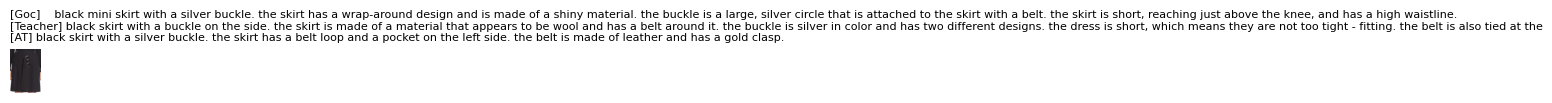

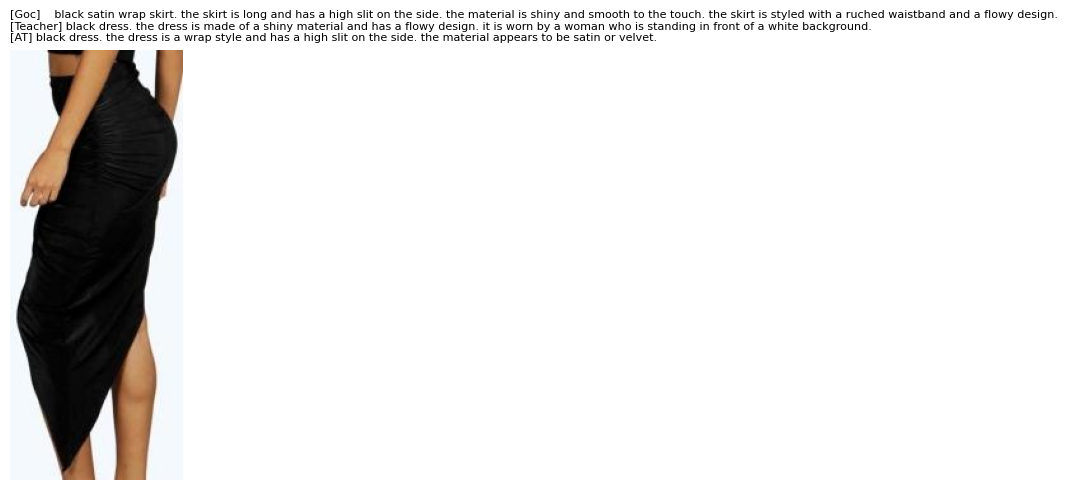

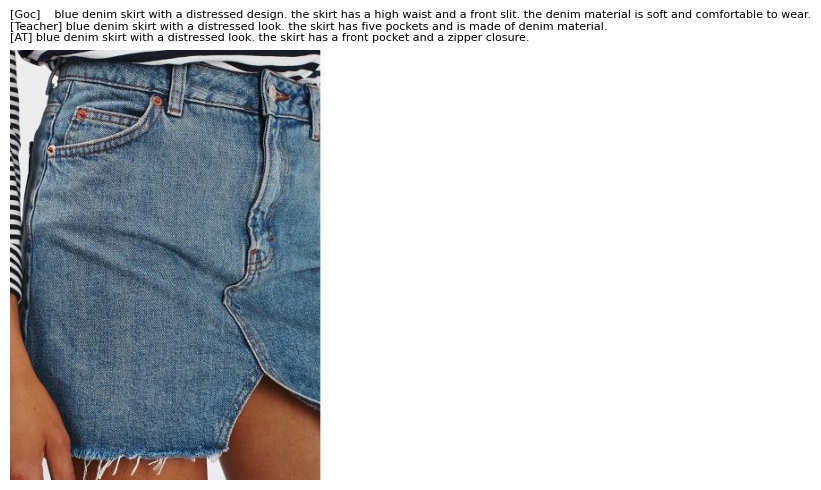

/tmp/ipykernel_58/2219634939.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


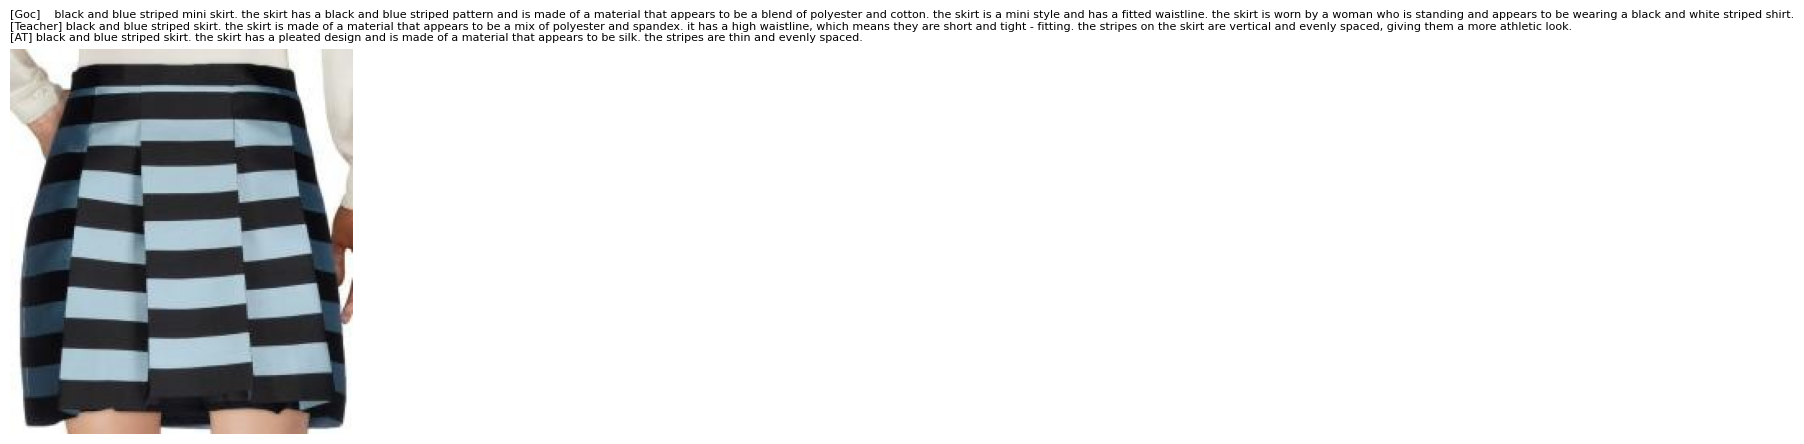

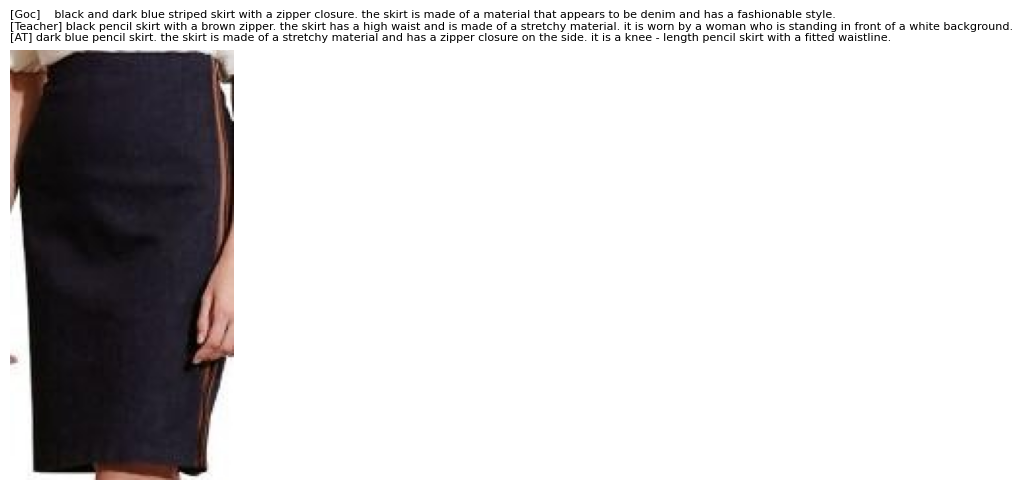

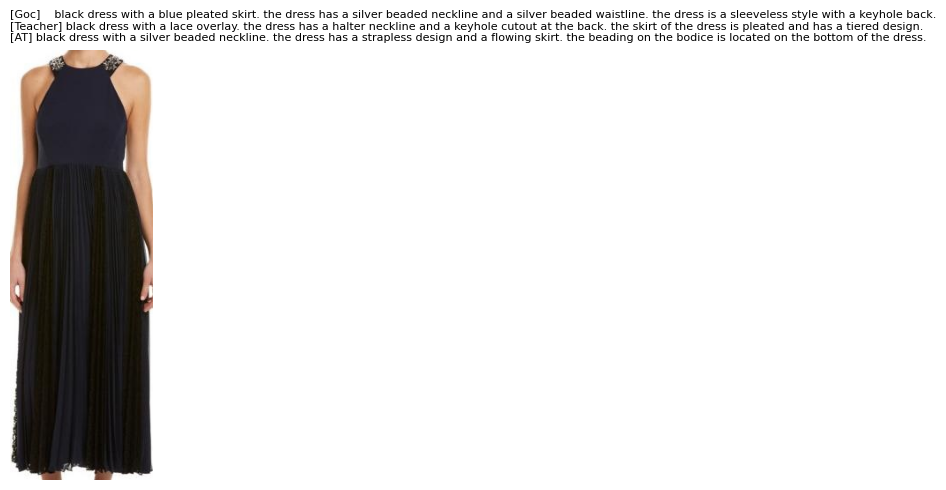

In [20]:
def show_qualitative_comparison(n_samples: int = 6, seed: int = RANDOM_SEED) -> None:
    rng = random.Random(seed)
    indices = rng.sample(range(len(fashion_test)), min(n_samples, len(fashion_test)))

    for idx in indices:
        item = fashion_test[idx]
        img = Image.open(item["image_path"]).convert("RGB")

        lines = [f"[Goc]    {item['caption']}"]

        t_inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(DEVICE)
        t_inputs["pixel_values"] = t_inputs["pixel_values"].half()
        with torch.no_grad():
            t_ids = teacher_model.generate(**t_inputs, **gen_cfg.as_kwargs(), logits_processor=MIN_SENTENCE_PROCESSOR)
        lines.append(f"[Teacher] {SHARED_PROCESSOR.decode(t_ids[0], skip_special_tokens=True)}")

        s_inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(DEVICE)
        with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=train_cfg.use_amp):
            s_ids = student.generate(**s_inputs, **gen_cfg.as_kwargs(), logits_processor=MIN_SENTENCE_PROCESSOR)
        cap = SHARED_PROCESSOR.decode(s_ids[0], skip_special_tokens=True)
        lines.append(f"[AT] {cap}")

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title("\n".join(lines), fontsize=8, loc="left")
        plt.tight_layout()
        plt.show()


show_qualitative_comparison(n_samples=6)


## 17. Lưu toàn bộ kết quả (để đối chiếu / viết thesis)

In [21]:
results_summary = {
    "accuracy": accuracy_results,
    "runtime": {k: {kk: vv for kk, vv in v.items() if kk != "throughput_by_batch"} for k, v in runtime_results.items()},
    "train_cost": train_cost_results,
    "train_loss_history": train_loss_history,
    "val_loss_history": val_loss_history,
    "arch_cfg": arch_cfg.__dict__,
    "train_cfg": train_cfg.__dict__,
    "gen_cfg": gen_cfg.__dict__,
    "method_name": run_cfg.method_name,
}
summary_path = os.path.join(run_cfg.output_root, "results_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2, default=str)

logger.info(f"Da luu tong hop ket qua -> {summary_path}")
logger.info(f"Checkpoint Teacher -> {os.path.join(run_cfg.output_root, 'teacher_checkpoint.pth')}")
logger.info(f"Checkpoint Student 'at' -> {best_ckpt_path}")


22:24:55 | INFO    | Da luu tong hop ket qua -> /kaggle/working/word_at_kd_outputs/results_summary.json
22:24:55 | INFO    | Checkpoint Teacher -> /kaggle/working/word_at_kd_outputs/teacher_checkpoint.pth
22:24:55 | INFO    | Checkpoint Student 'at' -> /kaggle/working/word_at_kd_outputs/best_student_at.pth


## 18. Upload kết quả + checkpoint lên HuggingFace Hub (tuỳ chọn)

Đổi `HF_USERNAME` / tên secret Kaggle (`HF_TOKEN...`) cho khớp tài khoản bạn dùng, giống quy ước ở
`pp1_2.ipynb`.


In [23]:
from huggingface_hub import HfApi, create_repo
from kaggle_secrets import UserSecretsClient

HF_USERNAME = "qa994"
HF_RESULTS_REPO = f"{HF_USERNAME}/blip-kd-results-word-at-fashion200k"


def get_hf_token() -> str:
    try:
        return UserSecretsClient().get_secret("HF_TOKEN2")
    except Exception as e:
        logger.warning(f"Khong lay duoc HF token tu Kaggle Secrets ({e}), thu dung bien moi truong.")
        token = os.environ.get("HF_TOKEN2")
        if not token:
            raise RuntimeError("Khong tim thay HF token. Them Kaggle Secret roi chay lai.") from e
        return token


hf_token = get_hf_token()
api = HfApi(token=hf_token)

try:
    create_repo(repo_id=HF_RESULTS_REPO, repo_type="dataset", token=hf_token, exist_ok=True, private=False)
except Exception as e:
    logger.error(f"Khong tao/xac nhan duoc repo {HF_RESULTS_REPO}: {e}")
    raise

logger.info(f"Dang upload {run_cfg.output_root} -> {HF_RESULTS_REPO} ...")
api.upload_folder(
    folder_path=run_cfg.output_root,
    repo_id=HF_RESULTS_REPO,
    repo_type="dataset",
    path_in_repo="kaggle_run_word_at",
    commit_message="Ket qua Kaggle: Word-KD + Attention Transfer (Optuna + early stopping)",
)
logger.info(f"Da upload xong -> https://huggingface.co/datasets/{HF_RESULTS_REPO}/tree/main/kaggle_run_word_at")


22:28:46 | INFO    | HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 200 OK"
22:28:46 | INFO    | Dang upload /kaggle/working/word_at_kd_outputs -> qa994/blip-kd-results-word-at-fashion200k ...
22:28:46 | INFO    | HTTP Request: POST https://huggingface.co/api/datasets/qa994/blip-kd-results-word-at-fashion200k/preupload/main "HTTP/1.1 200 OK"
22:29:27 | INFO    | HTTP Request: POST https://huggingface.co/api/datasets/qa994/blip-kd-results-word-at-fashion200k/commit/main "HTTP/1.1 200 OK"
22:29:27 | INFO    | Da upload xong -> https://huggingface.co/datasets/qa994/blip-kd-results-word-at-fashion200k/tree/main/kaggle_run_word_at
